In [1]:
import sys
import os


current_dir = os.getcwd()
if current_dir.endswith("notebooks"):
    os.chdir('..')

import src.config as config
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import glob
import numpy as np

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

C:\Users\HANIN\AppData\Local\Temp\ipykernel_11504\3366969949.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette="viridis")


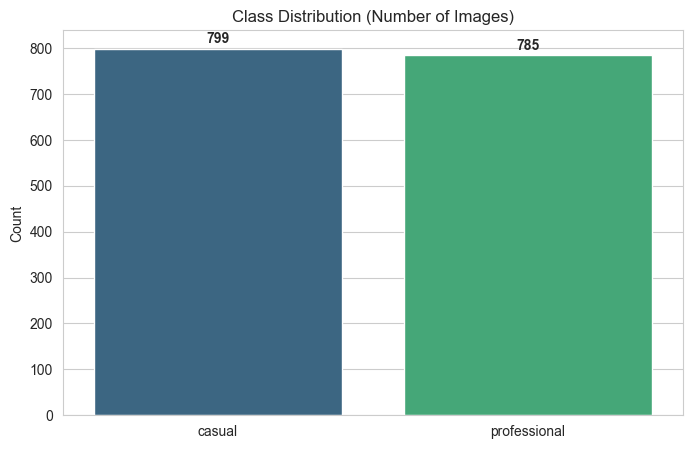

In [6]:
def plot_class_distribution(data_dir):
    classes = os.listdir(data_dir)
    counts = {}
    
    for c in classes:
        path = os.path.join(data_dir, c)
        if os.path.isdir(path):
            counts[c] = len(os.listdir(path))
            
    plt.figure(figsize=(8, 5))
    sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette="viridis")
    plt.title("Class Distribution (Number of Images)")
    plt.ylabel("Count")
    
    for i, count in enumerate(counts.values()):
        plt.text(i, count + 5, str(count), ha='center', va='bottom', fontweight='bold')
        
    plt.show()
    return counts


data_path = config.TRAIN_DIR
counts = plot_class_distribution(data_path)

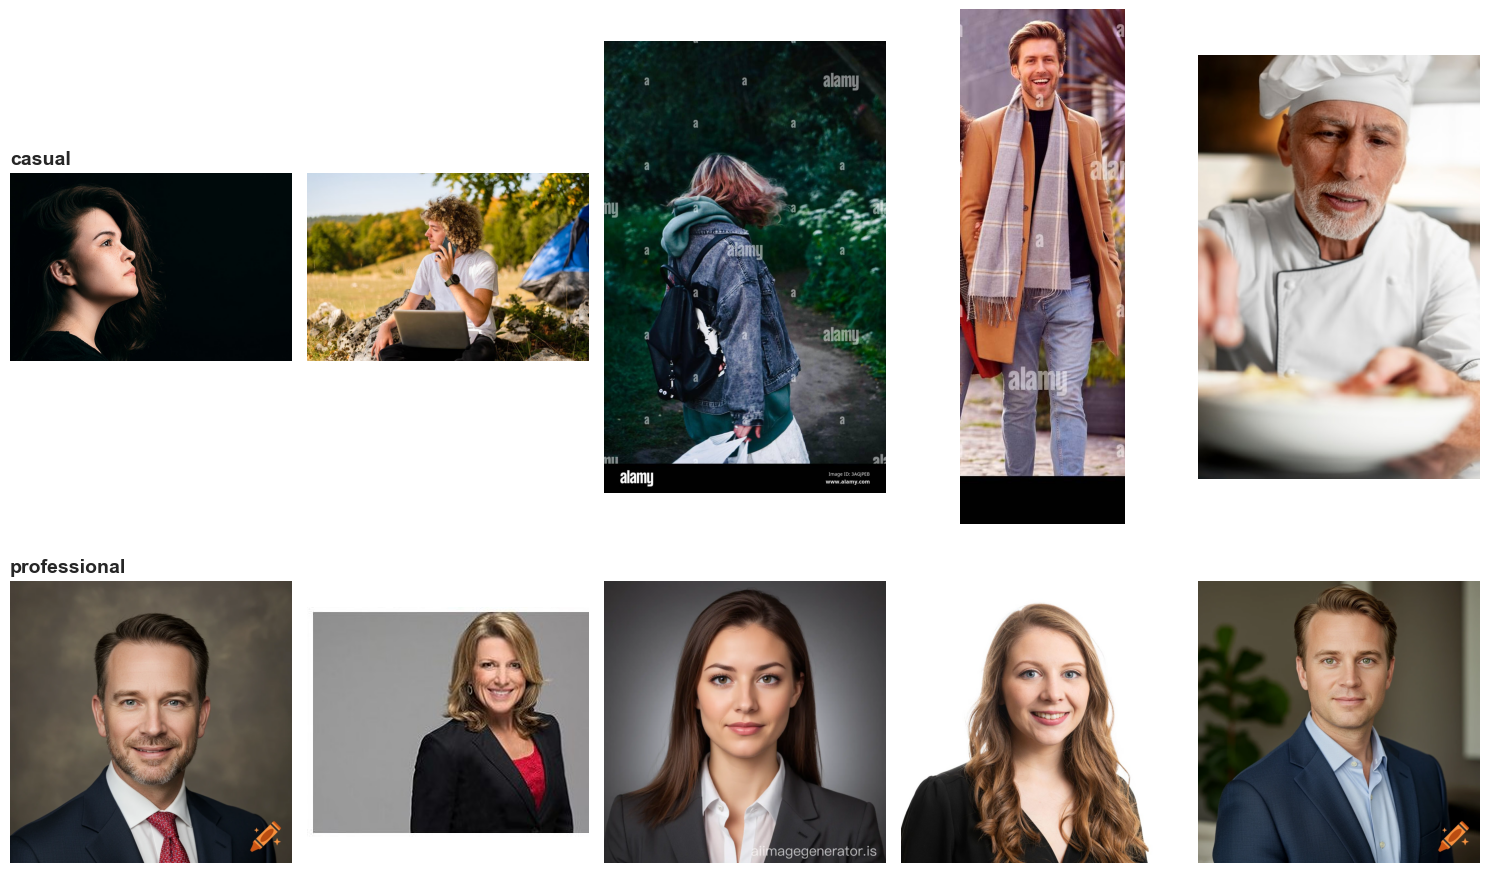

In [16]:
def show_samples(data_dir, num_samples=5):
    classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
    
    plt.figure(figsize=(15, 10))
    
    for i, class_name in enumerate(classes):
        image_paths = glob.glob(os.path.join(data_dir, class_name, "*"))
        sample_images = list(np.random.choice(image_paths, num_samples, replace=False))
        
        for j, img_path in enumerate(sample_images):
            plt.subplot(len(classes), num_samples, i * num_samples + j + 1)
            img = Image.open(img_path)
            plt.imshow(img)
            plt.axis("off")
            if j == 0:
                plt.title(class_name, fontsize=14, fontweight='bold', loc='left')
                
    plt.tight_layout()
    plt.show()

import numpy as np
show_samples(data_path)

Analyzing 1981 images... This might take a moment.


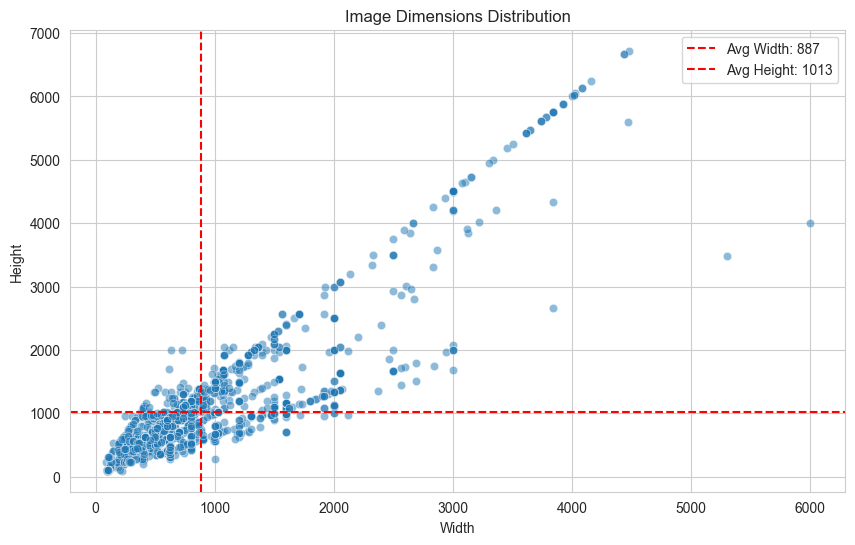

In [ ]:
def analyze_image_sizes(data_dir):
    widths = []
    heights = []
    
    all_images = glob.glob(os.path.join(data_dir, "*", "*"))
    print(f"Analyzing {len(all_images)} images")
    
    for img_path in all_images:
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)
        except:
            print(f"Corrupt image found: {img_path}")

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=widths, y=heights, alpha=0.5)
    plt.title("Image Dimensions Distribution")
    plt.xlabel("Width")
    plt.ylabel("Height")
    
    avg_w = np.mean(widths)
    avg_h = np.mean(heights)
    plt.axvline(avg_w, color='r', linestyle='--', label=f'Avg Width: {int(avg_w)}')
    plt.axhline(avg_h, color='r', linestyle='--', label=f'Avg Height: {int(avg_h)}')
    plt.legend()
    plt.show()

analyze_image_sizes(data_path)